Bessel 2-pole low pass

To convert this to a system of first-order ODEs, we choose $y_2 = y$ and $y_1 = \dot{y}$ to find
\begin{align}
\dot{y_1} &= 3(u(t) - y_2 - y_1) \\
\dot{y_2} &= y_1
\end{align}
Note that $y = y_2(t)$ here is the final variable of interest, representing the filter's output.


Next, we make it tuneable by adding a scaling factor:

\begin{align}
H(s) = \frac{3}{(\alpha s)^2 + 3\alpha s + 3}
\end{align}
for
\begin{align}
\ddot{y}(t) = \frac{3}{\alpha^2} u(t) - \frac{3}{\alpha^2} y(t) - \frac{3}{\alpha} \dot{y}(t)
\end{align}

This means we can set $\alpha$ using a cut-off frequency $f_c$ (in Hz) as:

\begin{align}
\alpha = \frac{1.3616}{2 \pi f_c}
\end{align}

We can also relate this to the first-order rise time, by setting it to the same cut-off frequency:

\begin{align}
\alpha = \frac{1.3616}{2 \pi f_c} = \frac{1.3616}{2 \pi \log(9) / (2 \pi t_r)} = \frac{1.3616}{\log(9)}t_r
\end{align}

This lets us compare 1st and 2nd order filters with the recordings from an EPC-10 again (see [appendix A4](./4-bessel-filters.ipynb)):

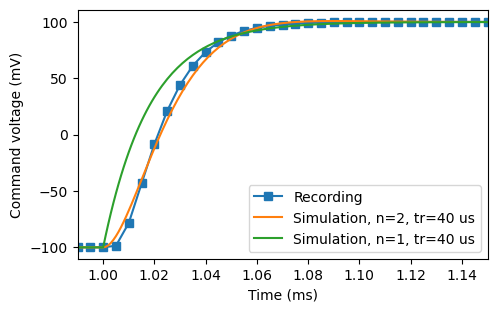

np.float64(0.018204784532536746)

In [10]:
# Load the "20us" data, which appears to have a rise time of 40us instead
d0 = myokit.DataLog.load('./res/stimulus-filter.zip')
d0 = d0.npview()

m = myokit.parse_model("""
[[model]]
filter.y1 = 0
filter.y2 = 0
filter.y3 = 0

[filter]
pace = 0 bind pace
time = 0 bind time
tr = 0.04 [ms] in [ms]
# Second-order
a2 = tr * 1.3616 / log(9)
    in [ms]
dot(y1) = 3 * (pace/a2^2 - y2/a2^2 - y1/a2)
dot(y2) = y1
# First-order
a1 = tr / log(9)
    in [ms]
dot(y3) = (pace - y3) / a1
""")

p = myokit.Protocol()
p.add_step(level=-100, duration=1)
p.add_step(level=100, duration=10)

s = myokit.Simulation(m, p)
s.pre(1)
d1 = s.run(2, log_interval=1e-3).npview()

fig = plt.figure(figsize=(5, 3))
fig.subplots_adjust(0.14, 0.15, 0.96, 0.98)
ax = fig.add_subplot()
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Command voltage (mV)')
ax.plot(d0.time(), d0['v20us'], 's-', label='Recording')
ax.plot(d1.time(), d1['filter.y2'], label=f'Simulation, n=2, tr=40 us')
ax.plot(d1.time(), d1['filter.y3'], label=f'Simulation, n=1, tr=40 us')
ax.legend()
ax.set_xlim(0.99, 1.15)
plt.show()

m.get('filter.a1').eval()